In [18]:
#Load the Iris dataset from sklearn.datasets.
from sklearn.datasets import load_iris
import pandas as pd
data,target=load_iris(return_X_y=True)
datas=load_iris()
data=pd.DataFrame(data)
target=pd.DataFrame(target)
# data.target[[10,25,50]]
# list(data.target_names)

In [111]:
data

In [113]:
# Preprocess and standardize the features
from sklearn.preprocessing import  StandardScaler
import sklearn.preprocessing as pre
quantile_transform=pre.QuantileTransformer(random_state=0)
data=quantile_transform.fit_transform(data)


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (150). n_quantiles is set to n_samples.
  warnings.warn(


In [89]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(

    data,target, test_size=0.33, random_state=42)

In [90]:


# model = keras.Sequential([
#     layers.Dense(256, activation='relu', input_shape=[X_train.shape[1]]),
#     layers.BatchNormalization(),
#     layers.Dense(256, activation='relu'),
#     layers.Dropout(0.3),
#     layers.BatchNormalization(),
#     layers.Dense(7, activation='relu')
# ])


In [91]:
# TensorFlow/Pytorch li-brary.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
inputs = layers.Input(shape=(X_train.shape[1],), name="digits")
x = layers.Dense(64, activation="relu", name="dense_1")(inputs)
x = layers.Dense(64, activation="relu", name="dense_2")(x)
outputs = layers.Dense(3, activation="softmax", name="predictions")(x)

model = keras.Model(inputs=inputs, outputs=outputs)


In [92]:
X_train, X_val, y_train, y_val = train_test_split(

    X_train,y_train, test_size=0.33, random_state=42)

In [94]:
#rain the model
model.compile(
    optimizer=keras.optimizers.RMSprop(),  # Optimizer
    # Loss function to minimize
    loss=keras.losses.SparseCategoricalCrossentropy(),
    # List of metrics to monitor
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)

#Report the training and validation accuracy/loss.
model.fit(X_train, y_train, batch_size=32, epochs=100,validation_data=(X_val,y_val))

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 445ms/step - loss: 0.1305 - sparse_categorical_accuracy: 0.9808 - val_loss: 0.3958 - val_sparse_categorical_accuracy: 0.8485
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1539 - sparse_categorical_accuracy: 0.9694 - val_loss: 0.2977 - val_sparse_categorical_accuracy: 0.9394
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1093 - sparse_categorical_accuracy: 0.9694 - val_loss: 0.2396 - val_sparse_categorical_accuracy: 0.9091
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1150 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.2851 - val_sparse_categorical_accuracy: 0.9394
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1033 - sparse_categorical_accuracy: 0.9734 - val_loss: 0.2367 - val_sparse_categorical_accuracy: 0.8788
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1261 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.2649 - val_sparse_categorical_accuracy: 0.9394
Epoch 7/100
3/3

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
(50, 1)
(50,)
(50, 1)


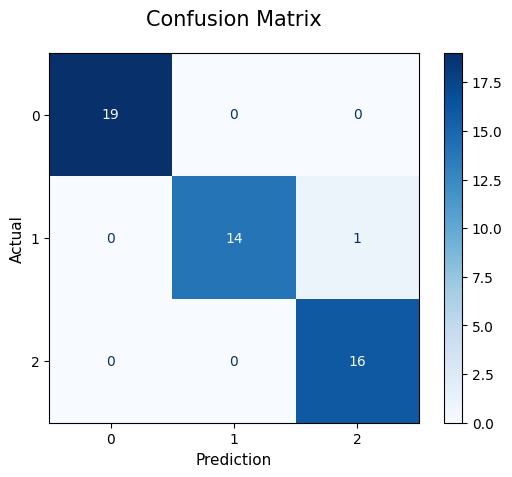

              precision    recall  f1-score   support

     class 0       1.00      1.00      1.00        19
     class 1       1.00      0.93      0.97        15
     class 2       0.94      1.00      0.97        16

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



In [111]:

import numpy as np
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay

import matplotlib.pyplot as plt

target_names = ['class 0', 'class 1', 'class 2']
classes=[0, 1, 2]
y_pred=model.predict(X_test)
print(y_test.shape)
k=np.argmax(y_pred,axis=-1)
print(k.shape)
k=np.reshape(k,(50,1))
k=pd.DataFrame(k)
print(k.shape)
cm = confusion_matrix(y_test, k, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix', fontsize=15, pad=20)
plt.xlabel('Prediction', fontsize=11)
plt.ylabel('Actual', fontsize=11)

plt.show()
# confusion matrix, test accu-racy, and classification report.

print(classification_report(y_test, np.argmax(y_pred,axis=-1), target_names=target_names))

2. (5)Experiment with hyperparameter tuning to optimize your FNN.
a Modify the following hyperparameters:
• Number of hidden layers or neurons.
• Learning rates.
• Batch size.
• Dropout layers
• Normalization
b Train the updated model and compare its accuracy with the original model.
c Provide updated plots for training and validation accuracy/loss, and evaluate
the new model on the test data.
d Discuss the impact of your changes and identify the best-performing configura-
tion.

In [126]:
# no of hidden layers =4
# leaniing rate=0.01
# batch_siz2 =128
# dropoutlayers=1
#normalization



# TensorFlow/Pytorch li-brary.
import tensorflow as tf
from tensorflow import keras
# from tensorflow.keras import layers
inputs2 = layers.Input(shape=(X_train.shape[1],), name="digits")
x = layers.Dense(128, activation="relu", name="dense_1")(inputs)
x = layers.Dense(128, activation="relu", name="dense_2")(x)
x = layers.Dense(128, activation="relu", name="dense_3")(x)
x = layers.Dense(128, activation="relu", name="dense_4")(x)
x = layers.Dense(128, activation="relu", name="dense_5")(x)
outputs = layers.Dense(3, activation="softmax", name="predictions")(x)
keras.layers.Dropout(0.2)

model2 = keras.Model(inputs=inputs, outputs=outputs)



#rain the model
model2.compile(
    optimizer=keras.optimizers.RMSprop(),  # Optimizer
    # Loss function to minimize
    loss=keras.losses.SparseCategoricalCrossentropy(),
    # List of metrics to monitor
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)

#Report the training and validation accuracy/loss.
model2.fit(X_train, y_train, batch_size=32, epochs=100,validation_data=(X_val,y_val))

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 518ms/step - loss: 1.0816 - sparse_categorical_accuracy: 0.6185 - val_loss: 1.0290 - val_sparse_categorical_accuracy: 0.6667
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.9978 - sparse_categorical_accuracy: 0.5876 - val_loss: 0.8839 - val_sparse_categorical_accuracy: 0.5455
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7972 - sparse_categorical_accuracy: 0.6984 - val_loss: 0.8406 - val_sparse_categorical_accuracy: 0.5152
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.7195 - sparse_categorical_accuracy: 0.6444 - val_loss: 0.6519 - val_sparse_categorical_accuracy: 0.5455
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5462 - sparse_categorical_accuracy: 0.6948 - val_loss: 0.6077 - val_sparse_categorical_accuracy: 0.5455
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.4793 - sparse_categorical_accuracy: 0.6948 - val_loss: 0.7539 - val_sparse_categorical_accuracy: 0.6364
Epoch 7/100
3/3

In [136]:
y1=model.predict(X_train)
y2=model2.predict(X_train)
print("////////////////////////////old model report on train data///////////////////////////////")

print(classification_report(y_train, np.argmax(y1,axis=-1), target_names=target_names))
print("////////////////////////////new model report on train data ///////////////////////////////")

print(classification_report(y_train, np.argmax(y2,axis=-1), target_names=target_names))


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
////////////////////////////old model report on train data///////////////////////////////
              precision    recall  f1-score   support

     class 0       1.00      1.00      1.00        24
     class 1       1.00      1.00      1.00        20
     class 2       1.00      1.00      1.00        23

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67

////////////////////////////new model report on train data ///////////////////////////////
              precision    recall  f1-score   support

     class 0       1.00      1.00      1.00        24
     class 1       0.59      1.00      0.74        20
     class 2       1.00      0.39      0.56        23

    accuracy                           0.79        67
   macro avg       0.86      0.80      0.77        67
weighted avg       0.88      0.79   

In [127]:
y_pred_new=model2.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


(50, 1)


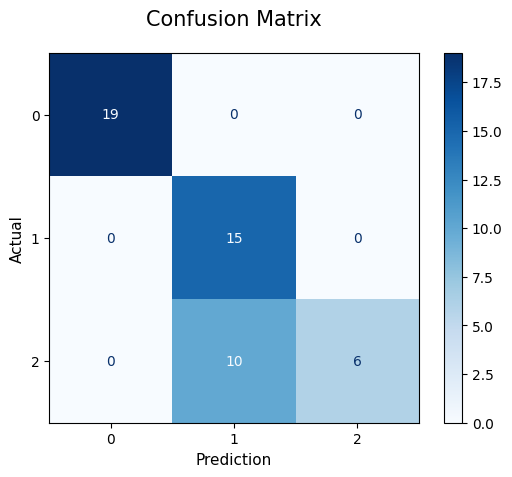

////////////////////////////old model report///////////////////////////////
              precision    recall  f1-score   support

     class 0       1.00      1.00      1.00        19
     class 1       1.00      0.93      0.97        15
     class 2       0.94      1.00      0.97        16

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50

////////////////////new model report///////////////////////////
              precision    recall  f1-score   support

     class 0       1.00      1.00      1.00        19
     class 1       0.60      1.00      0.75        15
     class 2       1.00      0.38      0.55        16

    accuracy                           0.80        50
   macro avg       0.87      0.79      0.77        50
weighted avg       0.88      0.80      0.78        50



In [134]:

target_names = ['class 0', 'class 1', 'class 2']
classes=[0, 1, 2]

print(y_test.shape)
k=np.argmax(y_pred_new,axis=-1)
# print(k.shape)
# k=np.reshape(k,(50,1))
# k=pd.DataFrame(k)
# print(k.shape)
cm = confusion_matrix(y_test, k, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix', fontsize=15, pad=20)
plt.xlabel('Prediction', fontsize=11)
plt.ylabel('Actual', fontsize=11)

plt.show()
# confusion matrix, test accu-racy, and classification report.
print("////////////////////////////old model report///////////////////////////////")
print(classification_report(y_test, np.argmax(y_pred,axis=-1), target_names=target_names))
print("////////////////////new model report///////////////////////////")

print(classification_report(y_test, np.argmax(y_pred_new,axis=-1), target_names=target_names))

In [ ]:
increasin the hidden layers and size of each layer effected the accuray
: on train data the accuracy was change to .79
: on the test data the accuracy changed to .80


In [ ]:
from sklearn.datasets import load_iris
import pandas as pd
data,target=load_iris(return_X_y=True)
datas=load_iris()
data=pd.DataFrame(data)
target=pd.DataFrame(target)